<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/assignments/Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

*Note: For the derivations below, it is assumed that the process noise $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ and measurement noise $z_k \sim \mathscr{N}(0, \Sigma_m)$ are independent of each other and of the prior state $x_{k-1}^+$.*

### 1. Show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$

Because $x_k^-$ is a linear combination of two independent Gaussian random vectors ($x^{+}_{k-1}$ and $w_{k-1}$), the resulting distribution is also Gaussian. 

**Mean:**
Applying the linearity of expectation:
$$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}]$$
$$m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$
Since $\mathbb{E}[w_{k-1}] = 0$, this simplifies to:
$$m_k^- = A_{k-1}m_{k-1}$$

**Covariance (Variance):**
Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent, the variance of their sum is the sum of their variances:
$$P_k^- = \text{Var}(x^-_k) = \text{Var}(A_{k-1}x^{+}_{k-1}) + \text{Var}(G_{k-1}w_{k-1})$$
$$P_k^- = A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

Thus, $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.

---

### 2. Show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$

Similarly, $y_k^-$ is a linear combination of two independent Gaussian random vectors ($x_k^-$ and $z_k$), so it is also Gaussian.

**Mean:**
$$\mathbb{E}[y^-_k] = \mathbb{E}[H_kx^-_k + z_k] = H_k\mathbb{E}[x^-_k] + \mathbb{E}[z_k]$$
Since $\mathbb{E}[z_k] = 0$, this simplifies to:
$$\mathbb{E}[y^-_k] = H_k m_k^-$$

**Covariance (Variance):**
Since $x_k^-$ and $z_k$ are independent:
$$\text{Var}(y^-_k) = \text{Var}(H_kx^-_k) + \text{Var}(z_k)$$
$$\text{Var}(y^-_k) = H_k\text{Var}(x^-_k)H_k^T + \text{Var}(z_k)$$
$$\text{Var}(y^-_k) = H_k P_k^- H_k^T + \Sigma_m$$

Thus, $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$.

---

### 3. Show the Joint Distribution of $x_k^-$ and $y_k^-$

Because $x_k^-$ and $y_k^-$ are linear transformations of jointly Gaussian variables, they are jointly Gaussian. We must find their cross-covariance matrix to complete the joint covariance matrix block.

**Cross-Covariance $\text{Cov}(x_k^-, y_k^-)$:**
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - \mathbb{E}[x_k^-])(y_k^- - \mathbb{E}[y_k^-])^T]$$
Substitute $y_k^- = H_kx_k^- + z_k$ and $\mathbb{E}[y_k^-] = H_km_k^-$:
$$y_k^- - \mathbb{E}[y_k^-] = H_k(x_k^- - m_k^-) + z_k$$
Now, substitute this into the covariance equation:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$
Because the state error is independent of the measurement noise $z_k$, the second expectation is zero. The first expectation is simply $P_k^-$. Therefore:
$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$

By symmetry, $\text{Cov}(y_k^-, x_k^-) = \text{Cov}(x_k^-, y_k^-)^T = H_k P_k^-$. 

Combining this with the marginal means and variances from Parts 1 and 2 yields the joint distribution:
$$
\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).
$$

---

### 4. Show that $x^{+}_k \sim \mathscr{N}(m_k, P_k)$

We rely on the standard theorem for conditional Gaussian distributions. If two random vectors are jointly Gaussian:
$$
\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)
$$
Then the conditional distribution $X \mid Y = y$ is $\mathscr{N}(\mu_{X|Y}, \Sigma_{X|Y})$, where:
$$\mu_{X|Y} = \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y - \mu_Y)$$
$$\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}$$

Using our matrix from Part 3, let $X = x_k^-$ and $Y = y_k^-$. 
Define the Kalman Gain $K_k$ as the term $\Sigma_{XY} \Sigma_{YY}^{-1}$:
$$K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

**Updated Mean ($m_k$):**
$$m_k = \mu_{X|Y} = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

**Updated Covariance ($P_k$):**
$$P_k = \Sigma_{X|Y} = P_k^- - K_k (H_k P_k^-)$$
Factoring out $P_k^-$ on the right gives:
$$P_k = (I - K_k H_k) P_k^-$$

Thus, $x^{+}_k \sim \mathscr{N}(m_k, P_k)$.

---

### 5. Find $\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$ and $\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$

Based directly on the conditional distribution derived in Part 4, the conditional expectation is the updated mean $m_k$, and the conditional variance is the updated covariance $P_k$.

**Conditional Expectation:**
$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

**Conditional Variance:**
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

### 1. The Prior (Predict Step)
We want to find the mean $m_k^-$ and variance $P_k^-$ of the predicted state $x^-_k$ given the previous state estimate $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$. The state equation is:
$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$

Since $x^+_{k-1}$ and the process noise $w_{k-1}$ are independent:

**Mean:**
Applying the linearity of expectation:
$$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1}]$$
$$m_k^- = a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}]$$
Since $w_{k-1} \sim \mathscr{N}(0,q)$, its expected value is $0$. Therefore:
$$m_k^- = a\,m_{k-1}$$

**Variance:**
Since the variables are independent, the variance of their sum is the sum of their variances:
$$P_k^- = \text{Var}(x^-_k) = \text{Var}(a\,x^+_{k-1}) + \text{Var}(w_{k-1})$$
$$P_k^- = a^2\text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1})$$
$$P_k^- = a^2 P_{k-1} + q$$

---

### 2. The Posterior (Update Step)
We want to update our estimate based on the observation $y^{\mathrm{obs}}_k$. The observation equation is $y^-_k = h\,x^-_k + z_k$. 

First, define the innovation (or measurement residual) $v_k$ and its variance $S_k$:
* **Innovation:** $v_k = y^{\mathrm{obs}}_k - \mathbb{E}[y^-_k] = y^{\mathrm{obs}}_k - h\,m_k^-$
* **Innovation Variance ($S_k$):** $\text{Var}(h\,x^-_k + z_k) = h^2 P_k^- + r$

The scalar Kalman gain $K_k$ is the covariance between the state and the measurement, divided by the measurement variance:
$$K_k = \frac{\text{Cov}(x^-_k, y^-_k)}{\text{Var}(y^-_k)} = \frac{h P_k^-}{h^2 P_k^- + r} = \frac{P_k^- h}{S_k}$$

Using the properties of conditional Gaussian distributions:

**Updated Mean ($m_k$):**
$$m_k = \mathbb{E}[x^-_k \mid y^-_k = y^{\mathrm{obs}}_k] = m_k^- + K_k v_k$$
$$m_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

**Updated Variance ($P_k$):**
$$P_k = \text{Var}(x^-_k \mid y^-_k = y^{\mathrm{obs}}_k) = P_k^- - K_k S_k K_k$$
Substituting $S_k K_k = P_k^- h$:
$$P_k = P_k^- - K_k (P_k^- h) = P_k^- - K_k h P_k^-$$
$$P_k = (1 - K_k h) P_k^-$$
Alternatively, substituting $K_k$ entirely:
$$P_k = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

---

### 3. Predictive Measurement Distribution
We want the distribution of the measurement $y^-_k$ given all previous observations $Y_{k-1}$.
$$y^-_k = h\,x^-_k + z_k$$
Given $Y_{k-1}$, we know $x^-_k \sim \mathscr{N}(m_k^-, P_k^-)$. Since $z_k \sim \mathscr{N}(0, r)$ is independent of $x^-_k$:

**Mean:**
$$\mathbb{E}[y^-_k \mid Y_{k-1}] = \mathbb{E}[h\,x^-_k + z_k \mid Y_{k-1}] = h\,m_k^- + 0 = h\,m_k^-$$

**Variance:**
$$\text{Var}(y^-_k \mid Y_{k-1}) = \text{Var}(h\,x^-_k + z_k \mid Y_{k-1}) = h^2\text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$$

Thus, the predictive measurement distribution is Gaussian:
$$p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

---

### 4. Posterior-Predictive Measurement Distribution
This asks for the distribution of the measurement if it were regenerated *after* observing $y^{\mathrm{obs}}_k$. Thus, we condition on $Y_k$.
Given $Y_k$, our state estimate is the posterior $x_k \sim \mathscr{N}(m_k, P_k)$.

**Mean:**
$$\mathbb{E}[y^-_k \mid Y_k] = \mathbb{E}[h\,x_k + z_k \mid Y_k] = h\,m_k + 0 = h\,m_k$$

**Variance:**
$$\text{Var}(y^-_k \mid Y_k) = \text{Var}(h\,x_k + z_k \mid Y_k) = h^2\text{Var}(x_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$$

Thus, the posterior-predictive distribution is:
$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

### 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm
from IPython.display import HTML

a = 1.0
q = 1.0
h = 1.0
r = 2.0
steps = 15
m0 = 0.0
P0 = 2.0

np.random.seed(42)

true_states = [m0]
measurements = []
priors = []
posteriors = []

m_prev = m0
P_prev = P0
x_true = m0

for k in range(steps):
    x_true = a * x_true + np.random.normal(0, np.sqrt(q))
    true_states.append(x_true)
    
    y_obs = h * x_true + np.random.normal(0, np.sqrt(r))
    measurements.append(y_obs)
    
    m_prior = a * m_prev
    P_prior = (a**2) * P_prev + q
    priors.append((m_prior, P_prior))
    
    v = y_obs - h * m_prior
    S = (h**2) * P_prior + r
    K = (P_prior * h) / S
    
    m_post = m_prior + K * v
    P_post = (1 - K * h) * P_prior
    posteriors.append((m_post, P_post))
    
    m_prev = m_post
    P_prev = P_post

fig, ax = plt.subplots(figsize=(10, 6))

x_axis = np.linspace(-15, 15, 1000)
ax.set_xlim(-15, 15)
ax.set_ylim(0, 0.6)
ax.set_title("1D Kalman Filter: Prior vs Posterior")
ax.set_xlabel("State Space (x)")
ax.set_ylabel("Probability Density")

prior_line, = ax.plot([], [], 'b--', lw=2, label="Prior (Predicted)")
post_line, = ax.plot([], [], 'g-', lw=2, label="Posterior (Updated)")
meas_line, = ax.plot([], [], 'ro', ms=8, label="Observation (y/h)")
true_line = ax.axvline(x=0, color='k', linestyle=':', lw=1.5, label="True State")

ax.legend(loc="upper left")
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes, fontsize=12)

def animate(i):
    m_prior, P_prior = priors[i]
    m_post, P_post = posteriors[i]
    y_val = measurements[i]
    x_t = true_states[i+1]
    
    prior_pdf = norm.pdf(x_axis, m_prior, np.sqrt(P_prior))
    post_pdf = norm.pdf(x_axis, m_post, np.sqrt(P_post))
    
    prior_line.set_data(x_axis, prior_pdf)
    post_line.set_data(x_axis, post_pdf)
    meas_line.set_data([y_val / h], [0.02])
    true_line.set_xdata([x_t, x_t])
    
    time_text.set_text(f'Time Step (k): {i+1}')
    
    return prior_line, post_line, meas_line, true_line, time_text

ani = animation.FuncAnimation(fig, animate, frames=steps, interval=800, blit=True)

plt.close(fig)

HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### 1. Deriving the State Transition Matrix $A$

The state transition matrix $A$ propagates the state forward in time from $k-1$ to $k$. For a "constant velocity" model, we assume the velocity remains constant over the time step $\Delta t$, and the position changes linearly according to that velocity.

The kinematic equations in 2D are:
1.  **Position X:** $p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$
2.  **Position Y:** $p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$
3.  **Velocity X:** $v_x(k) = v_x(k-1)$
4.  **Velocity Y:** $v_y(k) = v_y(k-1)$

We can write this system of linear equations in matrix form as $x^-_k = A x^+_{k-1}$:

$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}
$$

Thus, $A$ matches the required matrix.

---

### 2. Deriving the Measurement Matrix $H$

The measurement matrix $H$ maps the true state space into the observed measurement space. 

The problem states that our measurement $y_k$ consists *only* of the position components $(p_x(k), p_y(k))$. Therefore, we need to extract the 1st and 2nd elements of the state vector and ignore the 3rd and 4th elements (velocities).

The measurement equations are:
1.  $p_x^{\mathrm{meas}}(k) = 1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_{x,k}$
2.  $p_y^{\mathrm{meas}}(k) = 0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_{y,k}$

Writing this in matrix form $y_k = H x_k + z_k$:

$$
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
+
\begin{bmatrix}
z_{x,k}\\
z_{y,k}
\end{bmatrix}
$$

Thus, $H$ matches the required matrix.

---

### 3. Deriving the Process Noise Matrix $G$

In a constant velocity model, the velocity is never perfectly constant; it experiences random changes. We model this by assuming a random, constant acceleration acts on the system during the time interval $\Delta t$. 

Let the process noise vector be $w_{k-1} = \begin{bmatrix} a_x \\ a_y \end{bmatrix}$, where $a_x$ and $a_y$ are these random accelerations in the X and Y directions, respectively.

Using Newtonian kinematics, the effect of constant acceleration over a time step $\Delta t$ is:
* Change in Position: $\frac{1}{2} a \Delta t^2$
* Change in Velocity: $a \Delta t$

Adding these noise components to our state equations:
1.  **Noise added to $p_x$:** $\frac{1}{2} a_x \Delta t^2$
2.  **Noise added to $p_y$:** $\frac{1}{2} a_y \Delta t^2$
3.  **Noise added to $v_x$:** $a_x \Delta t$
4.  **Noise added to $v_y$:** $a_y \Delta t$

Writing the noise addition in matrix form $G w_{k-1}$:

$$
\begin{bmatrix}
\frac{1}{2} a_x \Delta t^2\\
\frac{1}{2} a_y \Delta t^2\\
a_x \Delta t\\
a_y \Delta t
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}
$$

Thus, $G$ matches the required matrix.

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

In [ ]:
pip install numpy matplotlib

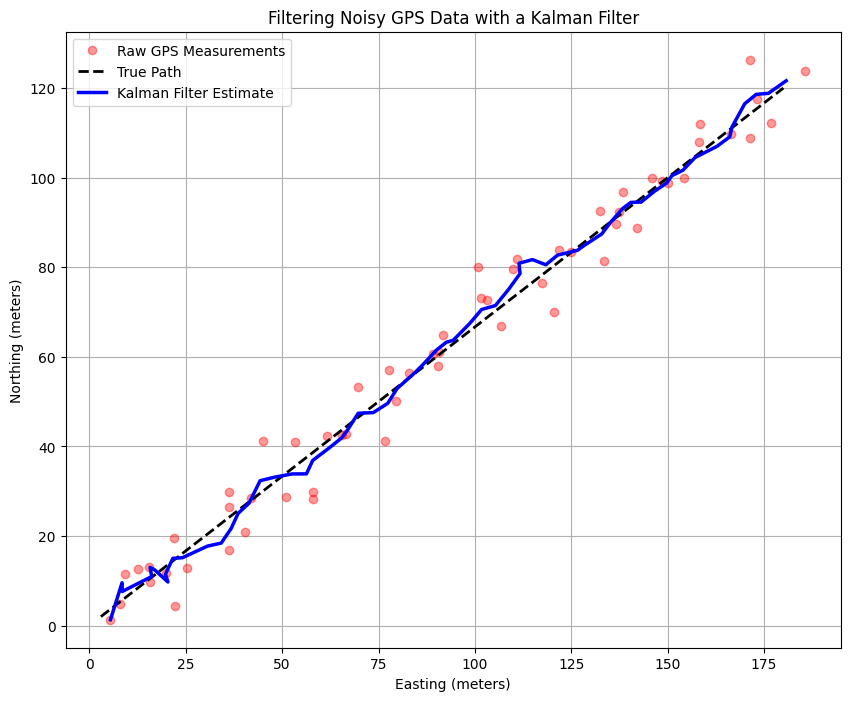

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class GPSKalmanFilter:
    def __init__(self, dt, sigma_a, sigma_m, initial_x=0.0, initial_y=0.0):
        self.dt = dt
        
        self.x = np.array([
            [initial_x],
            [initial_y],
            [0.0],
            [0.0]
        ])
        
        self.P = np.eye(4) * 100.0 
        
        self.A = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1]
        ])
        
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])
        
        G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])
        
        Sigma_p = np.array([
            [sigma_a**2, 0],
            [0, sigma_a**2]
        ])
        
        self.Q = G @ Sigma_p @ G.T
        
        self.R = np.array([
            [sigma_m**2, 0],
            [0, sigma_m**2]
        ])
        
        self.I = np.eye(4)

    def predict(self):
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x[0:2].flatten()

    def update(self, measurement):
        z = np.array([[measurement[0]], [measurement[1]]])
        
        v = z - (self.H @ self.x)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        self.x = self.x + (K @ v)
        self.P = (self.I - K @ self.H) @ self.P
        
        return self.x[0:2].flatten()

if __name__ == "__main__":
    dt = 1.0                
    num_steps = 60          
    gps_accuracy = 5.0      
    accel_variance = 0.2    
    
    true_vx, true_vy = 3.0, 2.0
    true_positions = []
    noisy_measurements = []
    
    current_x, current_y = 0.0, 0.0
    
    np.random.seed(42) 
    
    for _ in range(num_steps):
        current_x += true_vx * dt
        current_y += true_vy * dt
        true_positions.append((current_x, current_y))
        
        noisy_x = current_x + np.random.normal(0, gps_accuracy)
        noisy_y = current_y + np.random.normal(0, gps_accuracy)
        noisy_measurements.append((noisy_x, noisy_y))
        
    kf = GPSKalmanFilter(
        dt=dt, 
        sigma_a=accel_variance, 
        sigma_m=gps_accuracy, 
        initial_x=noisy_measurements[0][0], 
        initial_y=noisy_measurements[0][1]
    )
                         
    filtered_positions = []
    
    for z in noisy_measurements:
        kf.predict()                   
        est = kf.update(z)             
        filtered_positions.append(est) 
        
    true_x, true_y = zip(*true_positions)
    meas_x, meas_y = zip(*noisy_measurements)
    filt_x, filt_y = zip(*filtered_positions)
    
    plt.figure(figsize=(10, 8))
    plt.plot(meas_x, meas_y, 'ro', label='Raw GPS Measurements', alpha=0.4)
    plt.plot(true_x, true_y, 'k--', label='True Path', linewidth=2)
    plt.plot(filt_x, filt_y, 'b-', label='Kalman Filter Estimate', linewidth=2.5)
    
    plt.title('Filtering Noisy GPS Data with a Kalman Filter')
    plt.xlabel('Easting (meters)')
    plt.ylabel('Northing (meters)')
    plt.legend()
    plt.grid(True)
    plt.show()